# PDE Primer and Numerical Methods

This notebook is the first executable stop in the core path.

The goal is not to survey all **Partial Differential Equation (PDEs)** or all numerical methods. Instead, we use one narrow problem to build three pieces of intuition that will matter throughout the repo:

1. how to read a PDE as a constraint on an unknown function,
2. how a classical numerical method turns that constraint into a solvable linear system,
3. how automatic differentiation lets us compute the same derivatives needed by a PINN residual.

The canonical problem in this notebook is a 1D Poisson boundary value problem on `[0, 1]`.

## Notebook Contract

- **Status:** core-executable
- **Research question:** How do we move from a continuous PDE statement to a numerical baseline and then to derivative computations that a PINN can use?
- **Canonical problem:** 1D Poisson equation with Dirichlet boundary conditions
- **Prerequisites:** multivariable calculus, basic linear algebra, basic PyTorch tensors
- **Deliverable:** a working finite-difference solver, a convergence check, and an autograd-based residual computation
- **Estimated runtime:** under 1 minute on CPU
- **References:** standard finite differences for elliptic PDEs; PINN residual formulation from Raissi et al. (2019)
- **Next notebooks:** [02_vanilla_pinn_forward_problems.ipynb](02_vanilla_pinn_forward_problems.ipynb), [03_boundary_and_initial_conditions.ipynb](03_boundary_and_initial_conditions.ipynb)

## Why This Notebook Exists

PINNs can feel mysterious when introduced directly as a neural-network loss. A cleaner mental model is:

- first write the PDE in continuous form,
- then solve the same problem once with a classical baseline,
- then replace the discrete unknown vector with a differentiable function approximator.

That sequence keeps the physics constraint, the numerical baseline, and the learning formulation tied to the same object.

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
repo_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())

print(f"Repo root: {repo_root}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

Repo root: /home/duncan-nguyen/research/physics-informed-learning
NumPy: 2.4.3
PyTorch: 2.10.0+cu128
Device: cpu


## Canonical PDE

We solve the boundary value problem

$$
-u''(x) = f(x), \quad x \in (0, 1),
$$

with Dirichlet boundary conditions

$$
u(0) = 0, \quad u(1) = 0.
$$

We choose a manufactured solution

$$
u^*(x) = \sin(\pi x),
$$

which implies

$$
f(x) = \pi^2 \sin(\pi x).
$$

This problem is useful because it is simple, smooth, and has a known exact answer for validation.

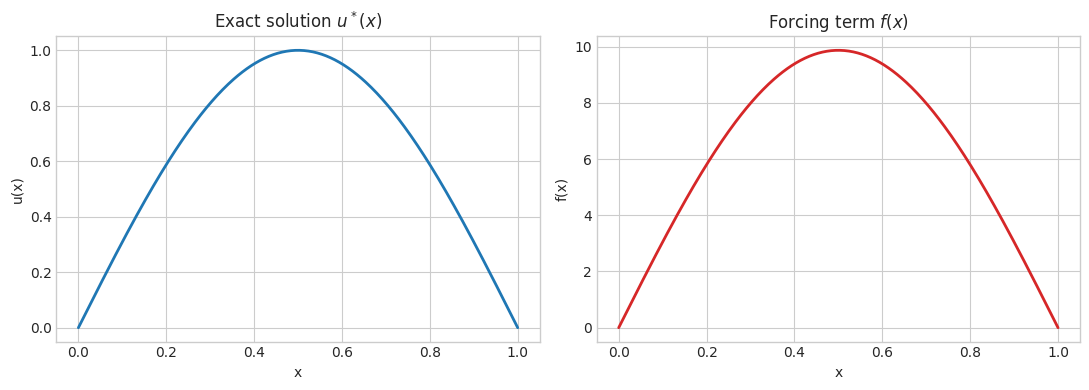

In [2]:
def exact_solution_np(x: np.ndarray) -> np.ndarray:
    return np.sin(np.pi * x)


def forcing_np(x: np.ndarray) -> np.ndarray:
    return (np.pi ** 2) * np.sin(np.pi * x)


def exact_solution_torch(x: torch.Tensor) -> torch.Tensor:
    return torch.sin(torch.pi * x)


def forcing_torch(x: torch.Tensor) -> torch.Tensor:
    return (torch.pi ** 2) * torch.sin(torch.pi * x)


x_plot = np.linspace(0.0, 1.0, 400)
u_plot = exact_solution_np(x_plot)
f_plot = forcing_np(x_plot)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_plot, u_plot, color="tab:blue", linewidth=2)
axes[0].set_title("Exact solution $u^*(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")

axes[1].plot(x_plot, f_plot, color="tab:red", linewidth=2)
axes[1].set_title("Forcing term $f(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f(x)")

plt.tight_layout()
plt.show()

## Finite-Difference Baseline

On a uniform grid with spacing $h$, the second derivative at an interior point $x_i$ is approximated by

$$
u''(x_i) \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}.
$$

Because our PDE is $-u''(x) = f(x)$, the discrete interior system becomes

$$
\frac{2u_i - u_{i-1} - u_{i+1}}{h^2} = f(x_i).
$$

This turns the continuous problem into a linear system $Au = b$ for the interior grid values. The boundary conditions are already known, so only the interior values are solved for.

Linear system shape: (39, 39)
Max error: 5.142e-04
L2 error:  3.591e-04


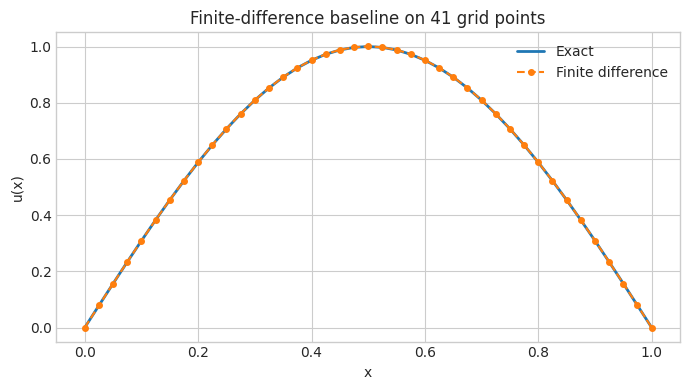

In [3]:
def solve_poisson_fd(num_grid_points: int):
    if num_grid_points < 3:
        raise ValueError("Need at least 3 grid points to have interior nodes.")

    x = np.linspace(0.0, 1.0, num_grid_points)
    h = x[1] - x[0]
    x_inner = x[1:-1]
    n_inner = len(x_inner)

    main_diag = 2.0 * np.ones(n_inner)
    off_diag = -1.0 * np.ones(n_inner - 1)
    A = (np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)) / (h ** 2)
    rhs = forcing_np(x_inner)

    u_inner = np.linalg.solve(A, rhs)
    u = np.zeros_like(x)
    u[1:-1] = u_inner
    return x, u, A


x_fd, u_fd, A_fd = solve_poisson_fd(num_grid_points=41)
u_exact_fd = exact_solution_np(x_fd)
max_error = np.max(np.abs(u_fd - u_exact_fd))
l2_error = np.sqrt(np.mean((u_fd - u_exact_fd) ** 2))

print(f"Linear system shape: {A_fd.shape}")
print(f"Max error: {max_error:.3e}")
print(f"L2 error:  {l2_error:.3e}")

plt.figure(figsize=(7, 4))
plt.plot(x_fd, u_exact_fd, label="Exact", linewidth=2)
plt.plot(x_fd, u_fd, "o--", markersize=4, label="Finite difference")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Finite-difference baseline on 41 grid points")
plt.legend()
plt.tight_layout()
plt.show()

Convergence study
n= 11 | h=0.10000 | max error=8.265e-03 | L2 error=5.573e-03
n= 21 | h=0.05000 | max error=2.059e-03 | L2 error=1.421e-03
n= 41 | h=0.02500 | max error=5.142e-04 | L2 error=3.591e-04
n= 81 | h=0.01250 | max error=1.285e-04 | L2 error=9.031e-05
n=161 | h=0.00625 | max error=3.213e-05 | L2 error=2.265e-05
Observed slope on max error vs h: 2.00


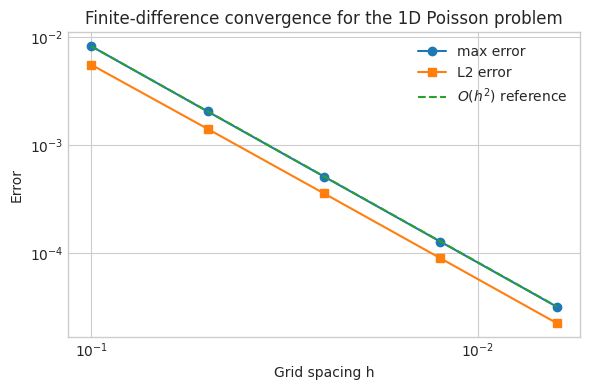

In [4]:
grid_sizes = [11, 21, 41, 81, 161]
hs = []
errors_max = []
errors_l2 = []

for n in grid_sizes:
    x_n, u_n, _ = solve_poisson_fd(n)
    u_exact_n = exact_solution_np(x_n)
    h_n = x_n[1] - x_n[0]
    hs.append(h_n)
    errors_max.append(np.max(np.abs(u_n - u_exact_n)))
    errors_l2.append(np.sqrt(np.mean((u_n - u_exact_n) ** 2)))

observed_order = np.polyfit(np.log(hs), np.log(errors_max), deg=1)[0]

print("Convergence study")
for n, h_n, emax, el2 in zip(grid_sizes, hs, errors_max, errors_l2):
    print(f"n={n:>3d} | h={h_n:.5f} | max error={emax:.3e} | L2 error={el2:.3e}")
print(f"Observed slope on max error vs h: {observed_order:.2f}")

plt.figure(figsize=(6, 4))
plt.loglog(hs, errors_max, "o-", label="max error")
plt.loglog(hs, errors_l2, "s-", label="L2 error")
reference = errors_max[0] * (np.array(hs) / hs[0]) ** 2
plt.loglog(hs, reference, "--", label="$O(h^2)$ reference")
plt.gca().invert_xaxis()
plt.xlabel("Grid spacing h")
plt.ylabel("Error")
plt.title("Finite-difference convergence for the 1D Poisson problem")
plt.legend()
plt.tight_layout()
plt.show()

## Why This Classical Baseline Matters

The finite-difference solver gives us three concrete anchors:

- a known numerical procedure for the same physics problem,
- an error curve that can be checked against theory,
- a reminder that not every PDE task needs a neural network.

In later notebooks, the point is not to replace classical solvers blindly. The point is to understand when a learned solver or a physics-informed model offers something useful beyond the baseline.

## Minimal Autodiff Bridge to PINNs

A PINN does not solve for discrete unknowns on a grid. Instead, it represents a function $u_\theta(x)$ and penalizes PDE violations at collocation points.

For the same problem, the residual is

$$
r_\theta(x) = -\frac{d^2 u_\theta}{dx^2}(x) - f(x).
$$

The only new ingredient we need is a way to compute derivatives of the model output with respect to the input coordinates. PyTorch autograd can already do this.

In [5]:
def gradient(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def second_derivative(y: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    return gradient(gradient(y, x), x)


x_collocation = torch.linspace(0.0, 1.0, 200, device=device).view(-1, 1)
x_collocation.requires_grad_(True)

u_exact_torch = exact_solution_torch(x_collocation)
u_x = gradient(u_exact_torch, x_collocation)
u_xx = second_derivative(u_exact_torch, x_collocation)
residual_exact = -u_xx - forcing_torch(x_collocation)

print(f"Max |u_x| for the exact solution: {u_x.abs().max().item():.3f}")
print(f"Max |residual| for the exact solution: {residual_exact.abs().max().item():.3e}")

Max |u_x| for the exact solution: 3.142
Max |residual| for the exact solution: 1.907e-06


Mean |residual| for the random network: 6.404
Boundary predictions at x=0 and x=1: [-0.03001272 -0.0930431 ]


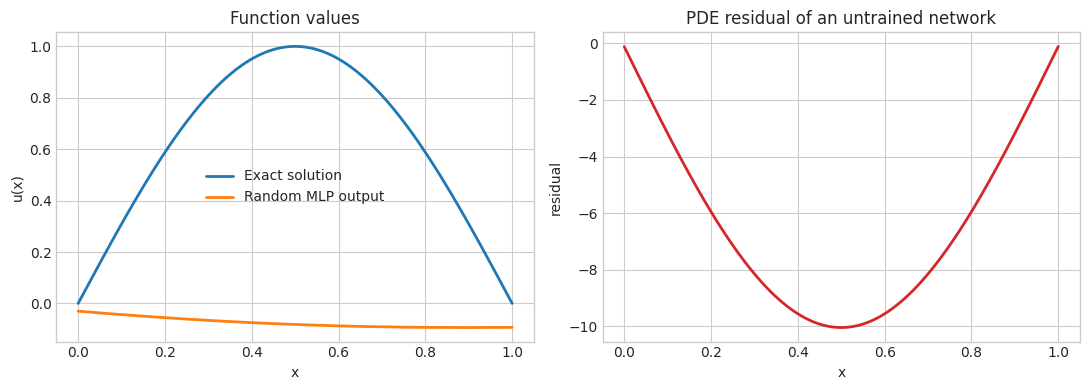

In [6]:
class SmallMLP(nn.Module):
    def __init__(self, width: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, width),
            nn.Tanh(),
            nn.Linear(width, width),
            nn.Tanh(),
            nn.Linear(width, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


model = SmallMLP().to(device)
x_model = torch.linspace(0.0, 1.0, 200, device=device).view(-1, 1)
x_model.requires_grad_(True)

u_model = model(x_model)
u_model_xx = second_derivative(u_model, x_model)
residual_model = -u_model_xx - forcing_torch(x_model)

boundary_points = torch.tensor([[0.0], [1.0]], device=device)
with torch.no_grad():
    boundary_values = model(boundary_points).cpu().numpy().ravel()

print(f"Mean |residual| for the random network: {residual_model.abs().mean().item():.3f}")
print(f"Boundary predictions at x=0 and x=1: {boundary_values}")

x_np = x_model.detach().cpu().numpy().ravel()
u_model_np = u_model.detach().cpu().numpy().ravel()
residual_model_np = residual_model.detach().cpu().numpy().ravel()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_np, exact_solution_np(x_np), label="Exact solution", linewidth=2)
axes[0].plot(x_np, u_model_np, label="Random MLP output", linewidth=2)
axes[0].set_title("Function values")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].legend()

axes[1].plot(x_np, residual_model_np, color="tab:red", linewidth=2)
axes[1].set_title("PDE residual of an untrained network")
axes[1].set_xlabel("x")
axes[1].set_ylabel("residual")

plt.tight_layout()
plt.show()

## Interpretation

The exact solution has essentially zero residual when differentiated with autograd, which is exactly what we want.

The random network does not satisfy either the boundary conditions or the PDE residual. That is also what we want to observe: the PINN training problem is precisely the problem of adjusting model parameters so that these physics violations become small.

## Key Takeaways

- A PDE is a constraint on an unknown function, not just a piece of notation.
- A classical baseline gives us a sanity check before we train any neural model.
- The same second derivative needed by a finite-difference stencil can also be computed from a differentiable model with autograd.
- This notebook does not train a PINN yet. It only builds the conceptual bridge needed for the next step.

## Next Step

Continue to [02_vanilla_pinn_forward_problems.ipynb](02_vanilla_pinn_forward_problems.ipynb), where the finite-difference baseline and the autograd residual are combined into the first full PINN training loop.